In [3]:
series_simpaths = ['data/examples/2d/md/phi-0.050/initial']

  
simpaths_torun = []    # list of simulations that need to be run/restarted

# sweep through variable values and find those that need to run/restart
for i in np.arange(len(series_simpaths)):
    simpath = series_simpaths[i]
    # NEED LOAD_SIMPATHS IF NOT FALSE

    # check to see if this value has already run to completion 
    try:
        restartjob = rm.check_restart(f"{PROJECT_ROOT}/{simpath}")    
            # returns True if in need of restart; False if completed; error if not run yet
    except:
        restartjob = True
        
    if restartjob:    # True if value needs to be run or restarted
        simpaths_torun.append(simpath)

0

In [1]:
import numpy as np
import os
import sys
cwd = os.getcwd()
itop=cwd.find("cgshells/")+len("cgshells")
PROJECT_ROOT = cwd[:itop]
sys.path.insert(0, PROJECT_ROOT)

import gzip
from utils.readsim import ReadSim
# from utils.curvsim.v1.curvamer2d import Curvamer2D
# from utils.curvsim.v1.curvamer3d import Curvamer3D

import matplotlib as mpl
import matplotlib.pyplot as plt

%matplotlib inline

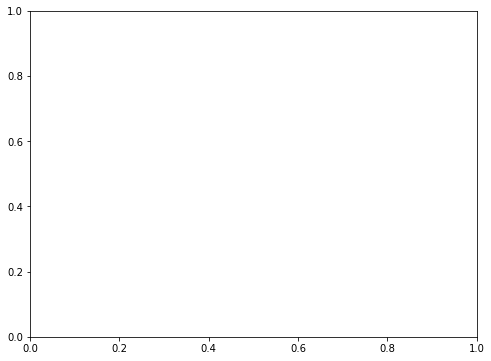

In [60]:
dimension = 2
dcore = 1
wx = 18.67 #56 * dcore
t0 = 1.0 * dcore
r0 = 34 * dcore
pair_ints = "1patch"
soft_ints = False
Nbeads = 20

sigma_list = np.array([0.25])
epsilon_list = np.array([0.004402158148617929, 0.004150479954762607, 0.003929396453109646, 0.003730849596132137, 0.0035518958894971996, 0.003388454184775002, 0.0032389044725140387, 0.003100496229191395, 0.0029727768768033633, 0.0028533075519276323, 0.0027424365265231476])
khlist = [1,100]

j = 9
sigma_list = [sigma_list[j]]
esilon_list = [epsilon_list[j]]

fig, ax = plt.subplots(1,1,figsize=(8,6))

for s in np.arange(len(sigma_list)):
    sigma = sigma_list[s]
    epsilon = epsilon_list[s]

    for i in np.arange(len(khlist)):
        try:
            ef = []
            eb = []
            n = []
            kh = khlist[i]
            fname = f"wx-{wx:0.3f}-t0-{t0:0.3f}-Nbeads-{Nbeads}-{pair_ints}-sigma-{sigma:0.5f}-epsilon-{epsilon:0.5f}-soft-{soft_ints}-kh-{kh:0.3f}-energies.txt"
            data = np.loadtxt(f"{PROJECT_ROOT}/jobs/sigma_eff/energies/{fname}")
            ef.append(data[:,1]/data[:,0])
            eb.append(data[:,2]/data[:,0])
            n.append(data[:,0])
            ef = np.array(ef)
            eb = np.array(eb)
            n = np.array(n)
            ax.plot(data[:,0],data[:,1]/data[:,0],"o-")
            
        except:
            pass
        

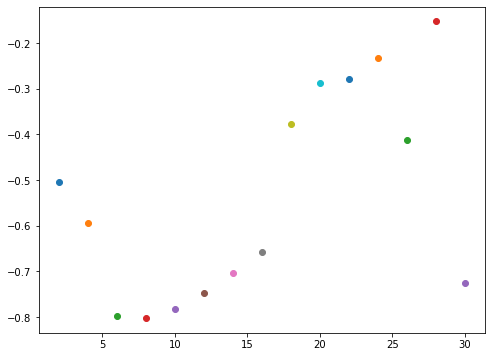

In [25]:
fig, ax = plt.subplots(1,1,figsize=(8,6))
ax.plot(n,ef,"o")

In [17]:
len(sigma_list)

11

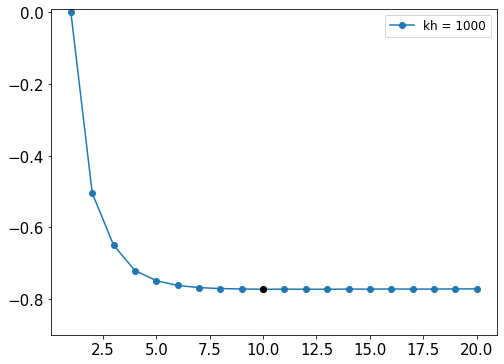

In [140]:
dimension = 2
dcore = 1
wx = 4.9 * dcore
t0 = 0.6 * dcore
r0 = 4.5 #20 * dcore
pair_ints = "1patch"
Nbeads = 15

sigma = 0.25 #0.25 * dcore
# epsilon = 0.004402158148617929
# khlist = [400,600,800,1000,1200]
khlist = [1000]
# khlist = [100,200,300,400,500,600,800,1000,1200]
# khlist = [100]
nshell_list = np.arange(1,20+1,1)

fig, ax = plt.subplots(1,1,figsize=(8,6))

nminlist = []
khmin = []

for kh in khlist:
    
    nmols = []
    energies = []
    
    for nshells in nshell_list:
        simpath = f"data/examples/{int(dimension)}d/emin/kh-{kh:0.2f}/nshells-{nshells}"
#         simpath = f"data/{int(dimension)}d/sigma-{sigma:0.3f}-kh-{kh:0.2f}/nshells-{nshells}"
#         simpath = f"data/{int(dimension)}d/wx-{wx:0.2f}-t0-{t0:0.2f}-r0-{r0:0.2f}-Nbeads-{Nbeads}-{pair_ints}/sigma-{sigma:0.3f}-kh-{kh:0.2f}/nshells-{nshells}"
#         simpath = f"data/{int(dimension)}d/stack-emin/wx-{wx:0.3f}-t0-{t0:0.3f}-Nbeads-{Nbeads}-r0-{r0:0.3f}/{pair_ints}/sigma-{sigma:0.5f}-soft-{soft_ints}/kh-{kh:0.3f}/nshells-{nshells}"
        try:
            simdir = f"{PROJECT_ROOT}/{simpath}" 
            # logname = "logmd.lammps"
    #             logname = "logemin.lammps"
            result = ReadSim(simdir)
            result.read_log()
            ef = result.energyf    # final energy
            energies.append(ef)
            nmols.append(nshells)
            
        except:
            pass
        
    nmols = np.array(nmols)
    energies = np.array(energies)
    ax.plot(nmols,energies/nmols,"o-",label=f"kh = {kh}")
    imin = np.argmin(energies/nmols)
    nmin = nmols[imin]
    emin = energies[imin]/nmin
    ax.plot(nmin,emin,"ko")
    nminlist.append(nmin)
    khmin.append(kh)

# ax.set_xlim(0,41)
ax.set_ylim(-0.9,0.01)
ax.legend(fontsize = 12)
ax.tick_params(labelsize=15)

In [32]:
t0 = 1
wx = 18.67
nu = 0.01
d = wx/(Nbeads-1)   # bead spacing
alpha = t0/d
kvkh = 2*(1-alpha**2 * nu)/(alpha**2 - nu)
kckh = nu*(1 + alpha**2)/(alpha**2 - nu)

In [34]:
kckh

0.019847286616730714

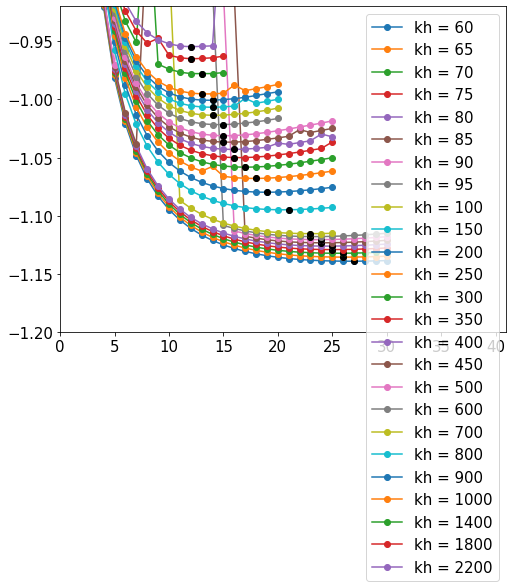

In [88]:
dimension = 2
dcore = 1
wx = 56 * dcore
t0 = 1 * dcore
r0 = 68 * dcore
pair_ints = "1patch"
Nbeads = 60

sigma = 1 * dcore
# khlist = [50,60,65,70,75,80,85,90,95,100,150,200,250,300,400,500,600,700,800,900,1000]
khlist = [60,65,70,75,80,85,90,95,100,150,200,250,300,350,400,450,500,600,700,800,900,1000]
khlist = [150,200,250,300,350,400,450,500,600,700,800,900,1000,1200,1400,1600,1800,2000,2200,2400]
khlist = [60,65,70,75,80,85,90,95,100,150,200,250,300,350,400,450,500,600,700,800,900,1000,1400,1800,2200]

nshell_list = np.arange(1,30+1,1)

fig, ax = plt.subplots(1,1,figsize=(8,6))

nminlist = []
khmin = []

for kh in khlist:
    
    nmols = []
    energies = []
    
    for nshells in nshell_list:
        
        simpath = f"data/{int(dimension)}d/wx-{wx:0.2f}-t0-{t0:0.2f}-r0-{r0:0.2f}-Nbeads-{Nbeads}-{pair_ints}/sigma-{sigma:0.3f}-kh-{kh:0.2f}/nshells-{nshells}"
        
        try:
            simdir = f"{PROJECT_ROOT}/{simpath}" 
            # logname = "logmd.lammps"
    #             logname = "logemin.lammps"
            result = ReadSim(simdir)
            result.read_log()
            ef = result.energyf    # final energy
            energies.append(ef)
            nmols.append(nshells)
            
        except:
            pass
        
    nmols = np.array(nmols)
    energies = np.array(energies)
    ax.plot(nmols,energies/nmols,"o-",label=f"kh = {kh}")
    imin = np.argmin(energies/nmols)
    nmin = nmols[imin]
    emin = energies[imin]/nmin
    ax.plot(nmin,emin,"ko")
    nminlist.append(nmin)
    khmin.append(kh)

ax.set_xlim(0,41)
ax.set_ylim(-1.2,-0.92)
ax.legend(fontsize = 15)
ax.tick_params(labelsize=15)

In [89]:
nminlist

[27,
 26,
 26,
 25,
 25,
 24,
 24,
 23,
 23,
 21,
 19,
 18,
 17,
 16,
 16,
 15,
 15,
 15,
 14,
 14,
 14,
 13,
 13,
 12,
 12]

In [90]:
khmin

[60,
 65,
 70,
 75,
 80,
 85,
 90,
 95,
 100,
 150,
 200,
 250,
 300,
 350,
 400,
 450,
 500,
 600,
 700,
 800,
 900,
 1000,
 1400,
 1800,
 2200]

In [72]:
def sconformal(h):
    return (2-2*np.sqrt(h**2+1))/h + np.arcsinh(h)

(0.0, 30.0)

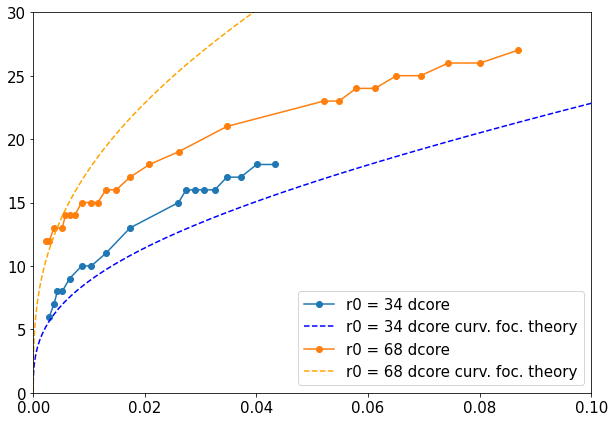

In [101]:
nlist = np.linspace(0.1,50,100)
r034_nmin = np.array([18, 18, 17, 17, 16, 16, 16, 16, 15, 13, 11, 10, 10, 9, 8, 8, 7, 6])
r034_kh = np.array([60,65,70,75,80,85,90,95,100,150,200,250,300,400,500,600,700,900])

r034_eflat = np.array([0.67778081661165,0.734262551329287,0.790744286046925,0.847226020764563,0.903707755482201,
          0.960189490199837,1.01667122491747,1.07315295963511,1.12963469435275,1.69445204152913,
          2.25926938870551,2.82408673588189,3.38890408305828,4.51853877741103,5.64817347176377,
          6.77780816611652,7.90744286046928,10.1667122491748])
r034_tk0 = (t0+dcore)/34

r068_nmin = np.array([27,26,26,25,25,24,24,23,23,21,19,18,17,16,16,15,15,15,14,14,14,13,13,12,12])
r068_kh = np.array([60,65,70,75,80,85,90,95,100,150,200,250,300,350,400,450,500,600,700,800,900,1000,1400,1800,2200])
r068_eflat = np.array([0.169425633028391,0.183544435780758,0.197663238533124,0.21178204128549,
                       0.225900844037855,0.240019646790221,0.254138449542588,0.268257252294953,
                       0.282376055047319,0.423564082570979,0.564752110094638,0.705940137618298,
                       0.847128165141959,0.98831619266562,1.12950422018928,1.27069224771294,1.41188027523659,
                       1.69425633028392,1.97663238533124,2.25900844037856,2.54138449542588,2.82376055047319,
                       3.95326477066247,5.08276899085175,6.21227321104102])
r068_tk0 = (t0+dcore)/68

fig, ax = plt.subplots(1,1,figsize=(10,7))

ax.plot(1*r034_tk0/(2*r034_eflat), r034_nmin,"o-",label="r0 = 34 dcore")
ax.plot(sconformal(nlist*r034_tk0),nlist,"b--",label="r0 = 34 dcore curv. foc. theory")

ax.plot(1*r068_tk0/(2*r068_eflat), r068_nmin,"o-",label="r0 = 68 dcore")
ax.plot(sconformal(nlist*r068_tk0),nlist,"--",color="orange",label="r0 = 68 dcore curv. foc. theory")

ax.tick_params(labelsize=15)
ax.legend(fontsize=15)
ax.set_xlim(0,0.1)
ax.set_ylim(0,30)

In [102]:
0.5**(-4/3)

2.5198420997897464